# Optimizer profile: scaling with model size
Step time and peak memory against parameter count $P$, Sven against the baselines. Two families: the 3-hidden-layer MNIST MLP (width 32 to 2048) and the 4-layer nanoGPT (embedding width 64 to 512). Red crosses mark the first size at which a method ran out of memory or was analytically infeasible.

In [1]:
import sys
import os
# This notebook lives in analysis/notebooks/<group>/, but every analysis path is
# relative to analysis/ (plots_v2/, tables/, ../experiment_results), so run from there
# with the helper modules in analysis/lib/ on the path.
_A = os.getcwd()
while not all(os.path.isdir(os.path.join(_A, d)) for d in ('lib', 'notebooks')):
    _A, _prev = os.path.dirname(_A), _A
    if _A == _prev:
        raise RuntimeError('analysis/ not found above ' + os.getcwd())
os.chdir(_A)
sys.path.insert(0, _A)
sys.path.insert(0, os.path.join(_A, 'lib'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from style import set_style
import profile_helpers as ph
set_style()
PLOT_DIR = 'plots_v2/profile'
# $SV3_PROFILE_ROOT > profile_results_v3 (the re-measurement, once its 720 configurations
# are all there) > profile_results_v2.  A PARTIAL v3 is announced and skipped, not used.
ROOT = ph.results_root()         # prints which root it chose
df = ph.load_profiles(ROOT)      # one tidy row per configuration
ARCHS = [a for a in ph.ARCH_ORDER if a in set(df.arch)]
df.groupby(['arch', 'study']).size().unstack(fill_value=0)
WIDTH = [a for a in ['mnist_width', 'nanogpt_width'] if a in set(df.arch)]

profile results: /n/home/anon/sven-experiments/profile_results_v3  (v3)


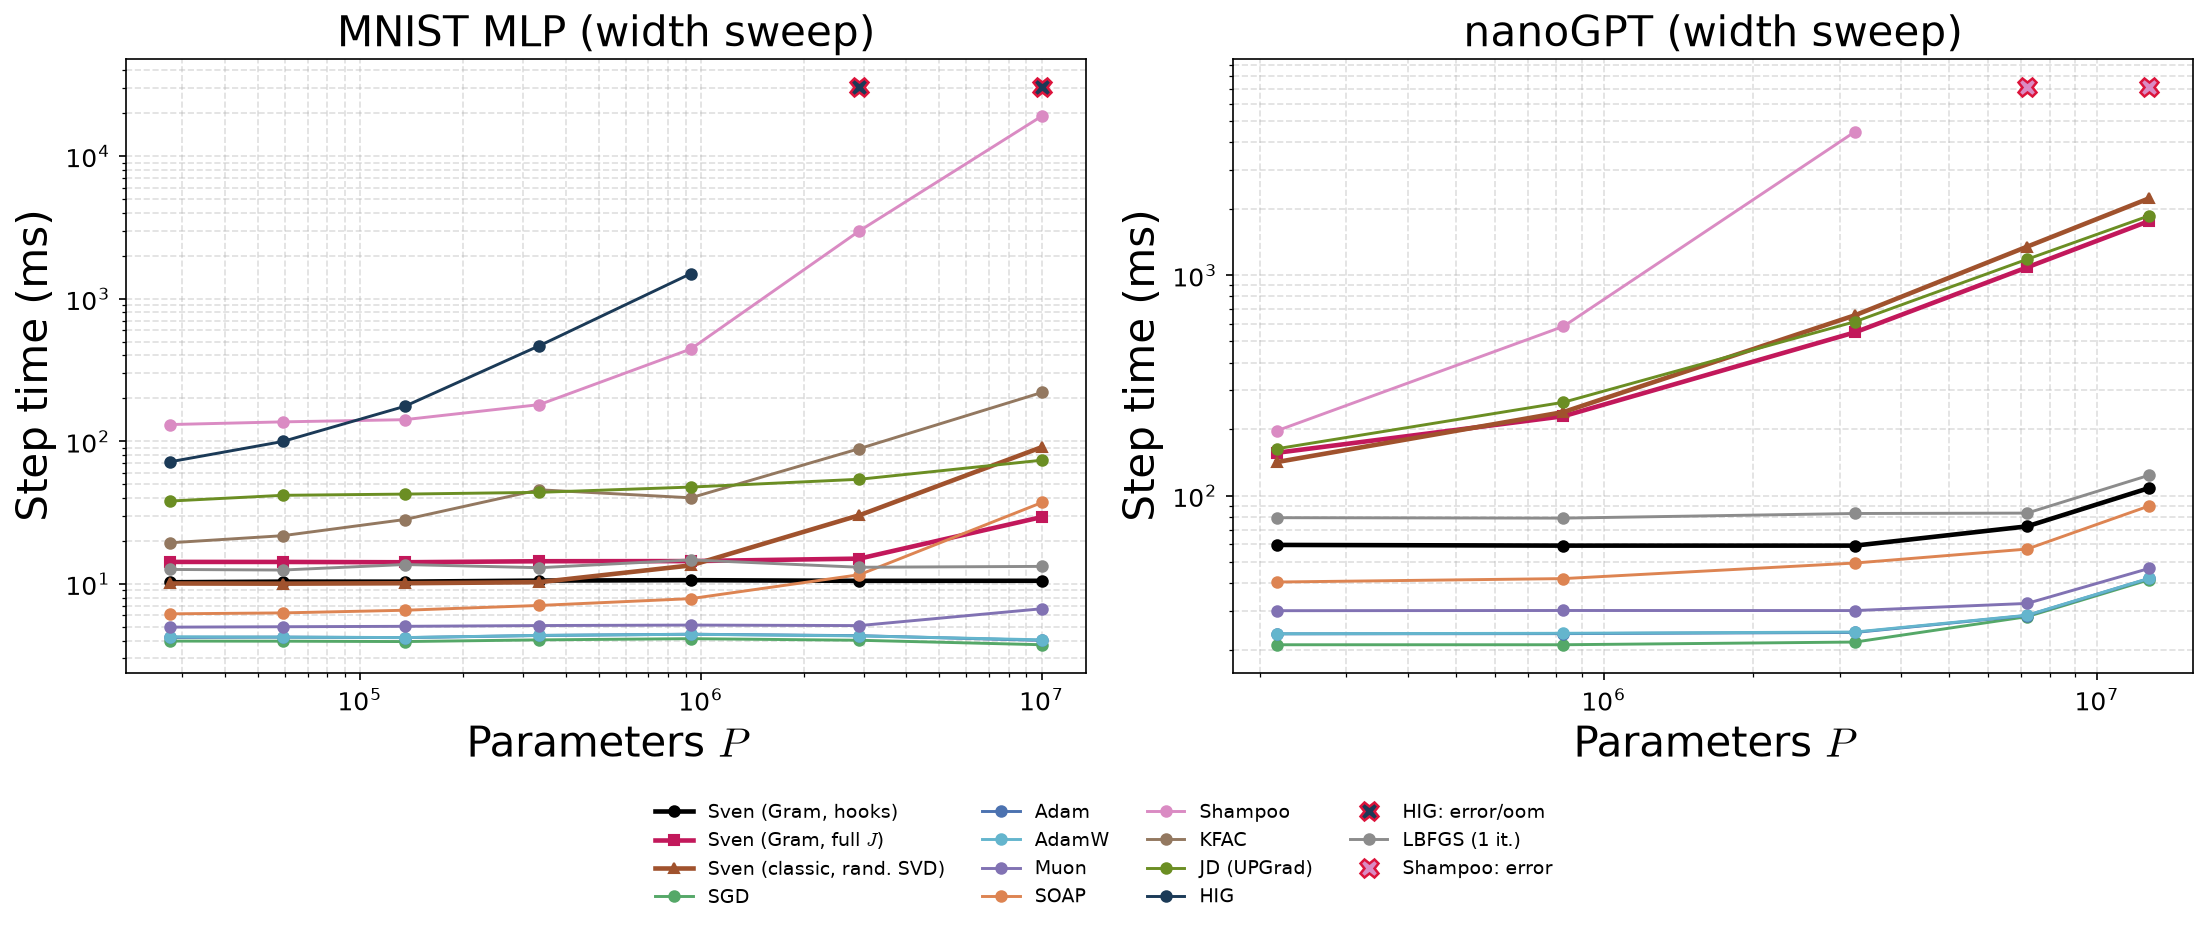

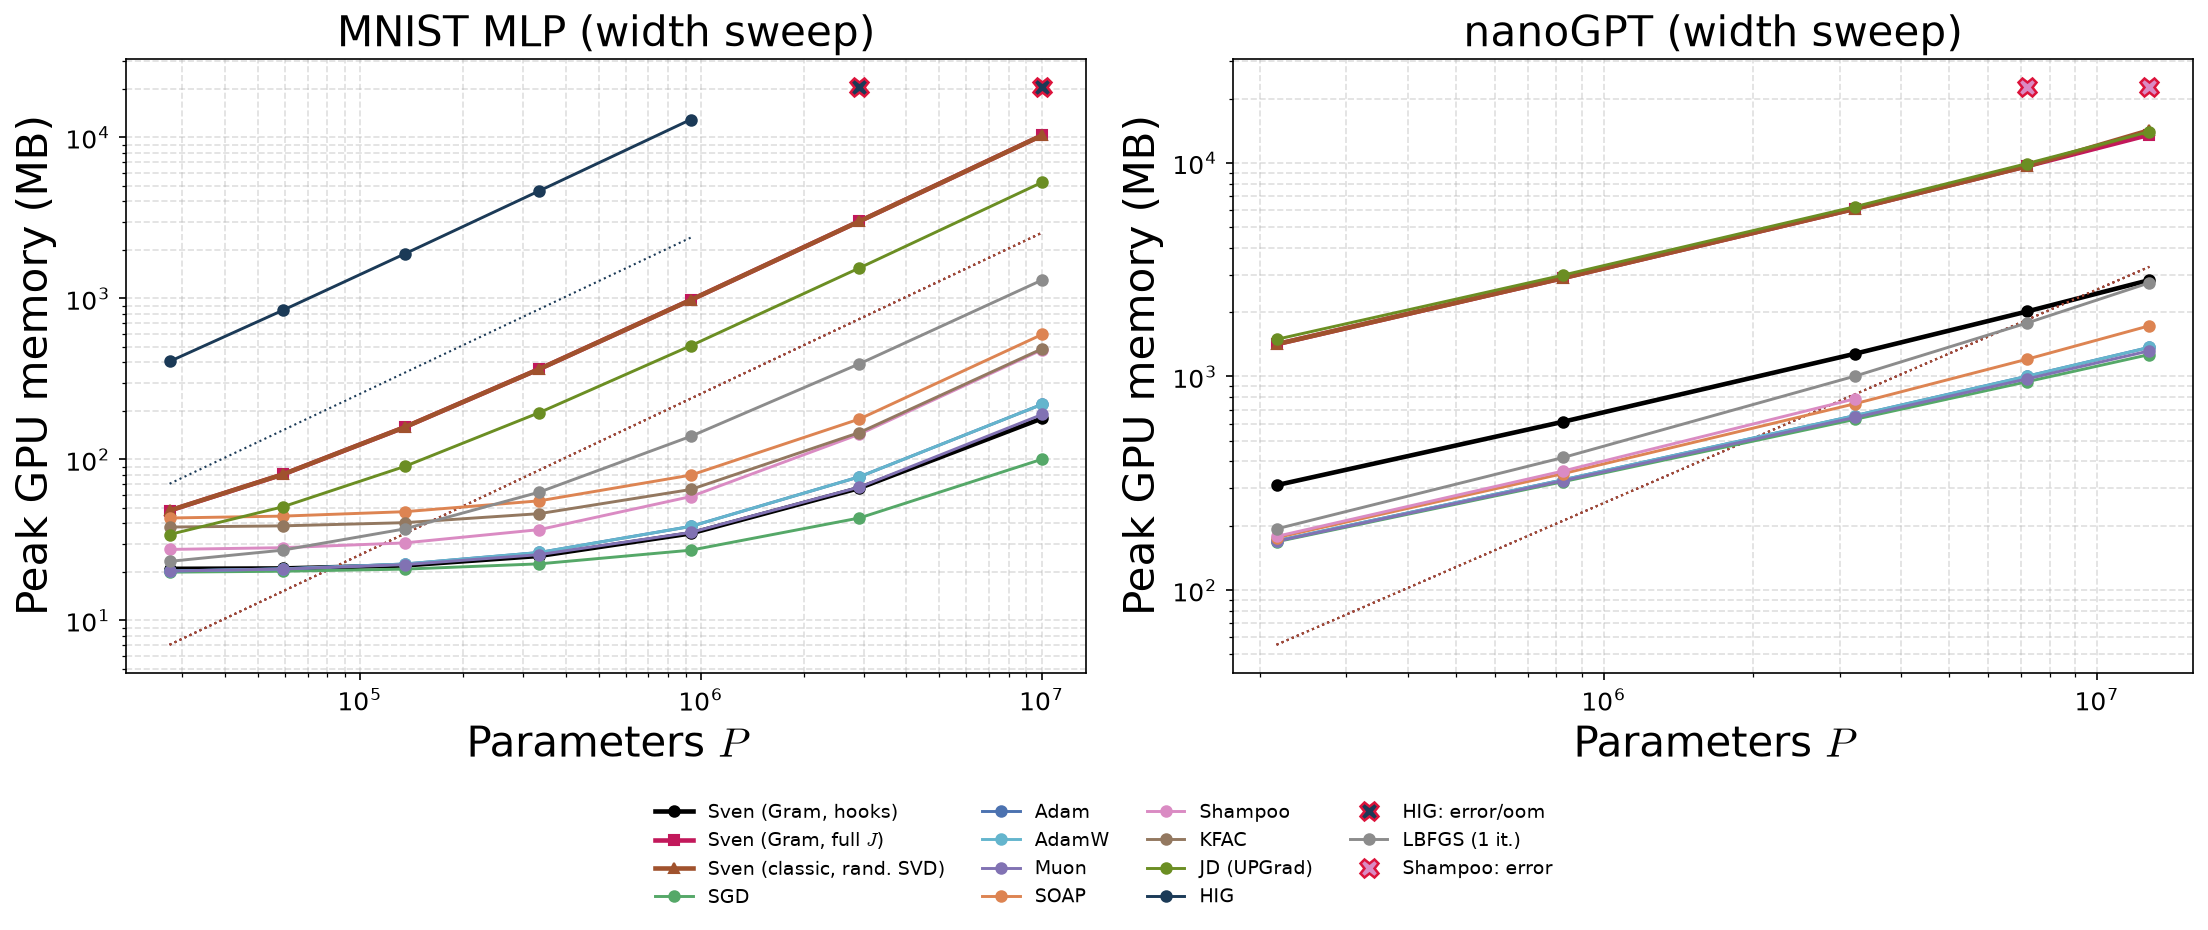

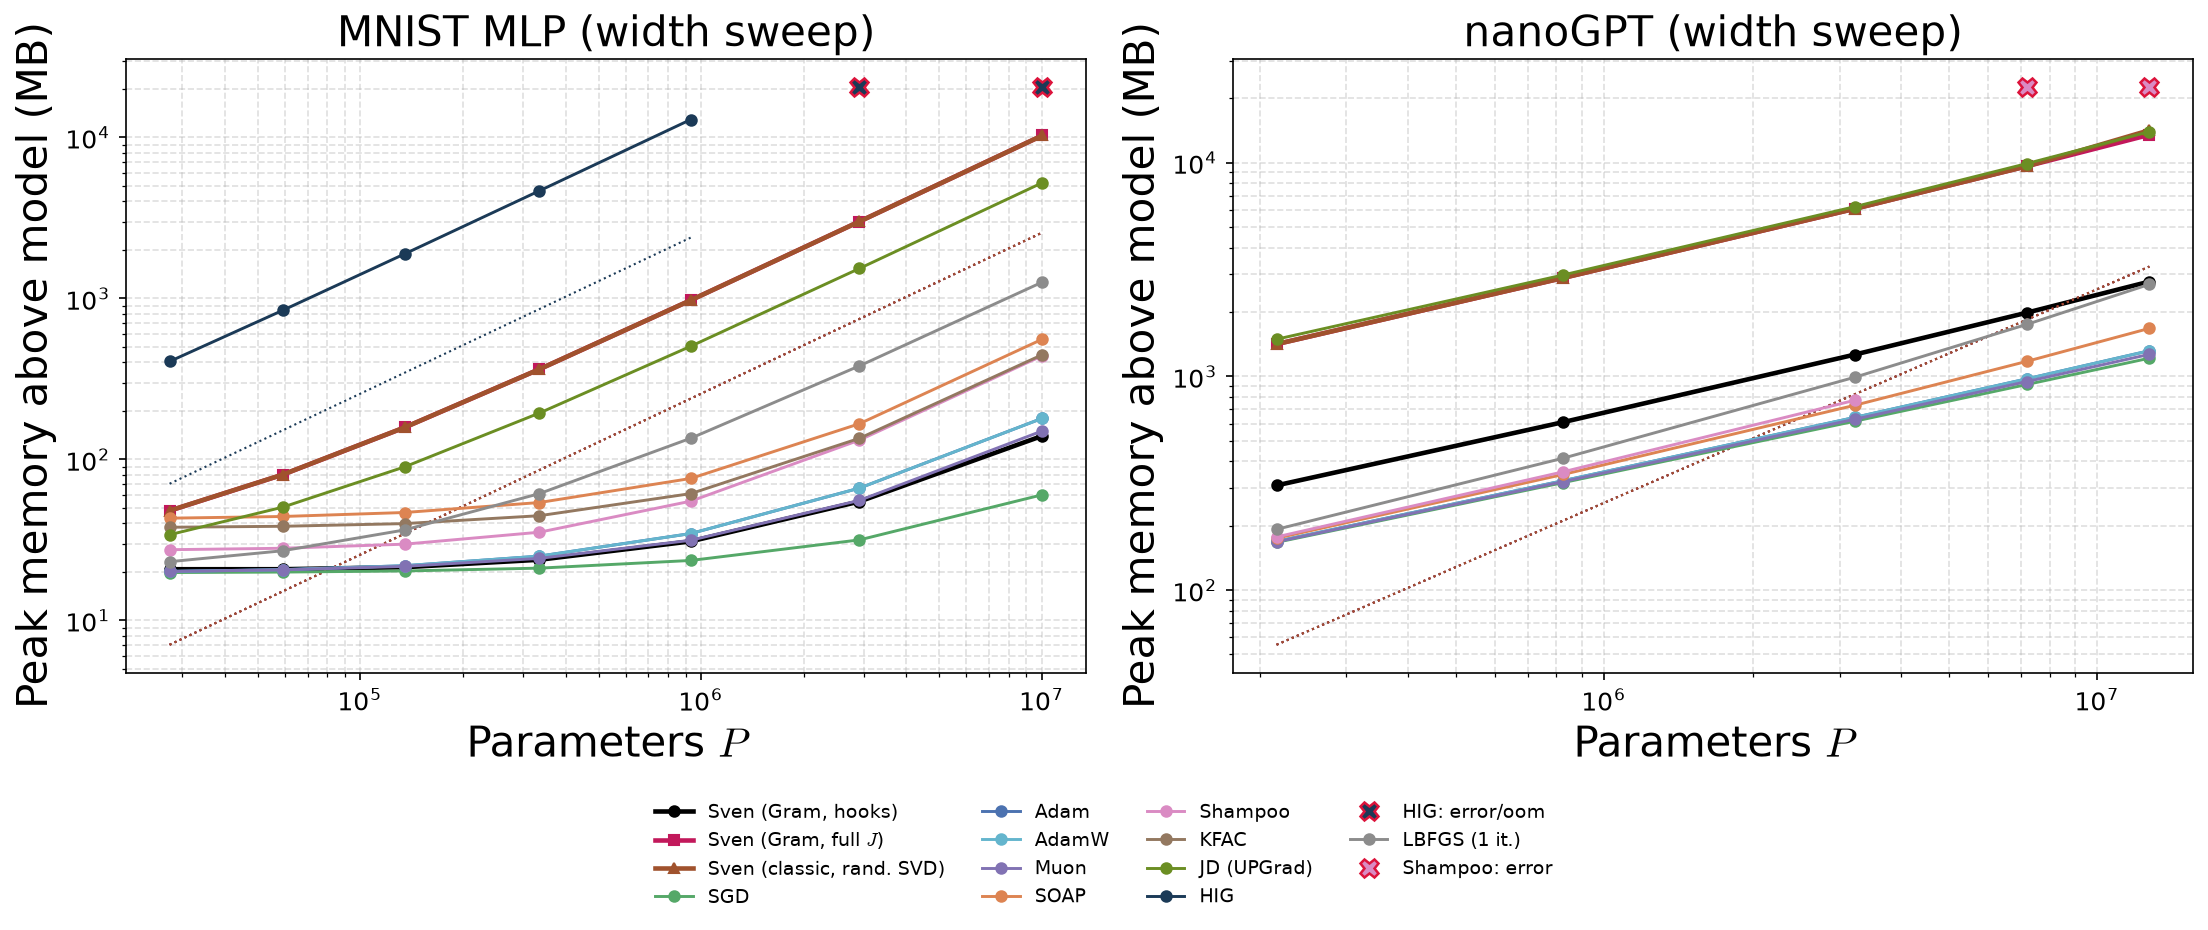

In [2]:
for value, fname in [('step_ms', 'scaling_step_time'), ('peak_mb', 'scaling_peak_memory'), ('overhead_mb', 'scaling_memory_overhead')]:
    fig, axes = plt.subplots(1, len(WIDTH), figsize=(7.5 * len(WIDTH), 5.5), squeeze=False)
    for ax, arch in zip(axes[0], WIDTH):
        ph.plot_sweep(df, arch, 'width', 'n_params', ax, value=value, analytic='analytic_jac_mb' if value != 'step_ms' else None)
        ax.set_xscale('log')
    ph.legend_below(fig, axes[0][0])
    fig.tight_layout(); ph.save(fig, f'{fname}.pdf', PLOT_DIR); plt.show()

### Sven variants only
The Gram/hooks path never forms the Jacobian, so its memory should track the model; the full-Jacobian paths carry the $B P\cdot 4$-byte block (dotted).

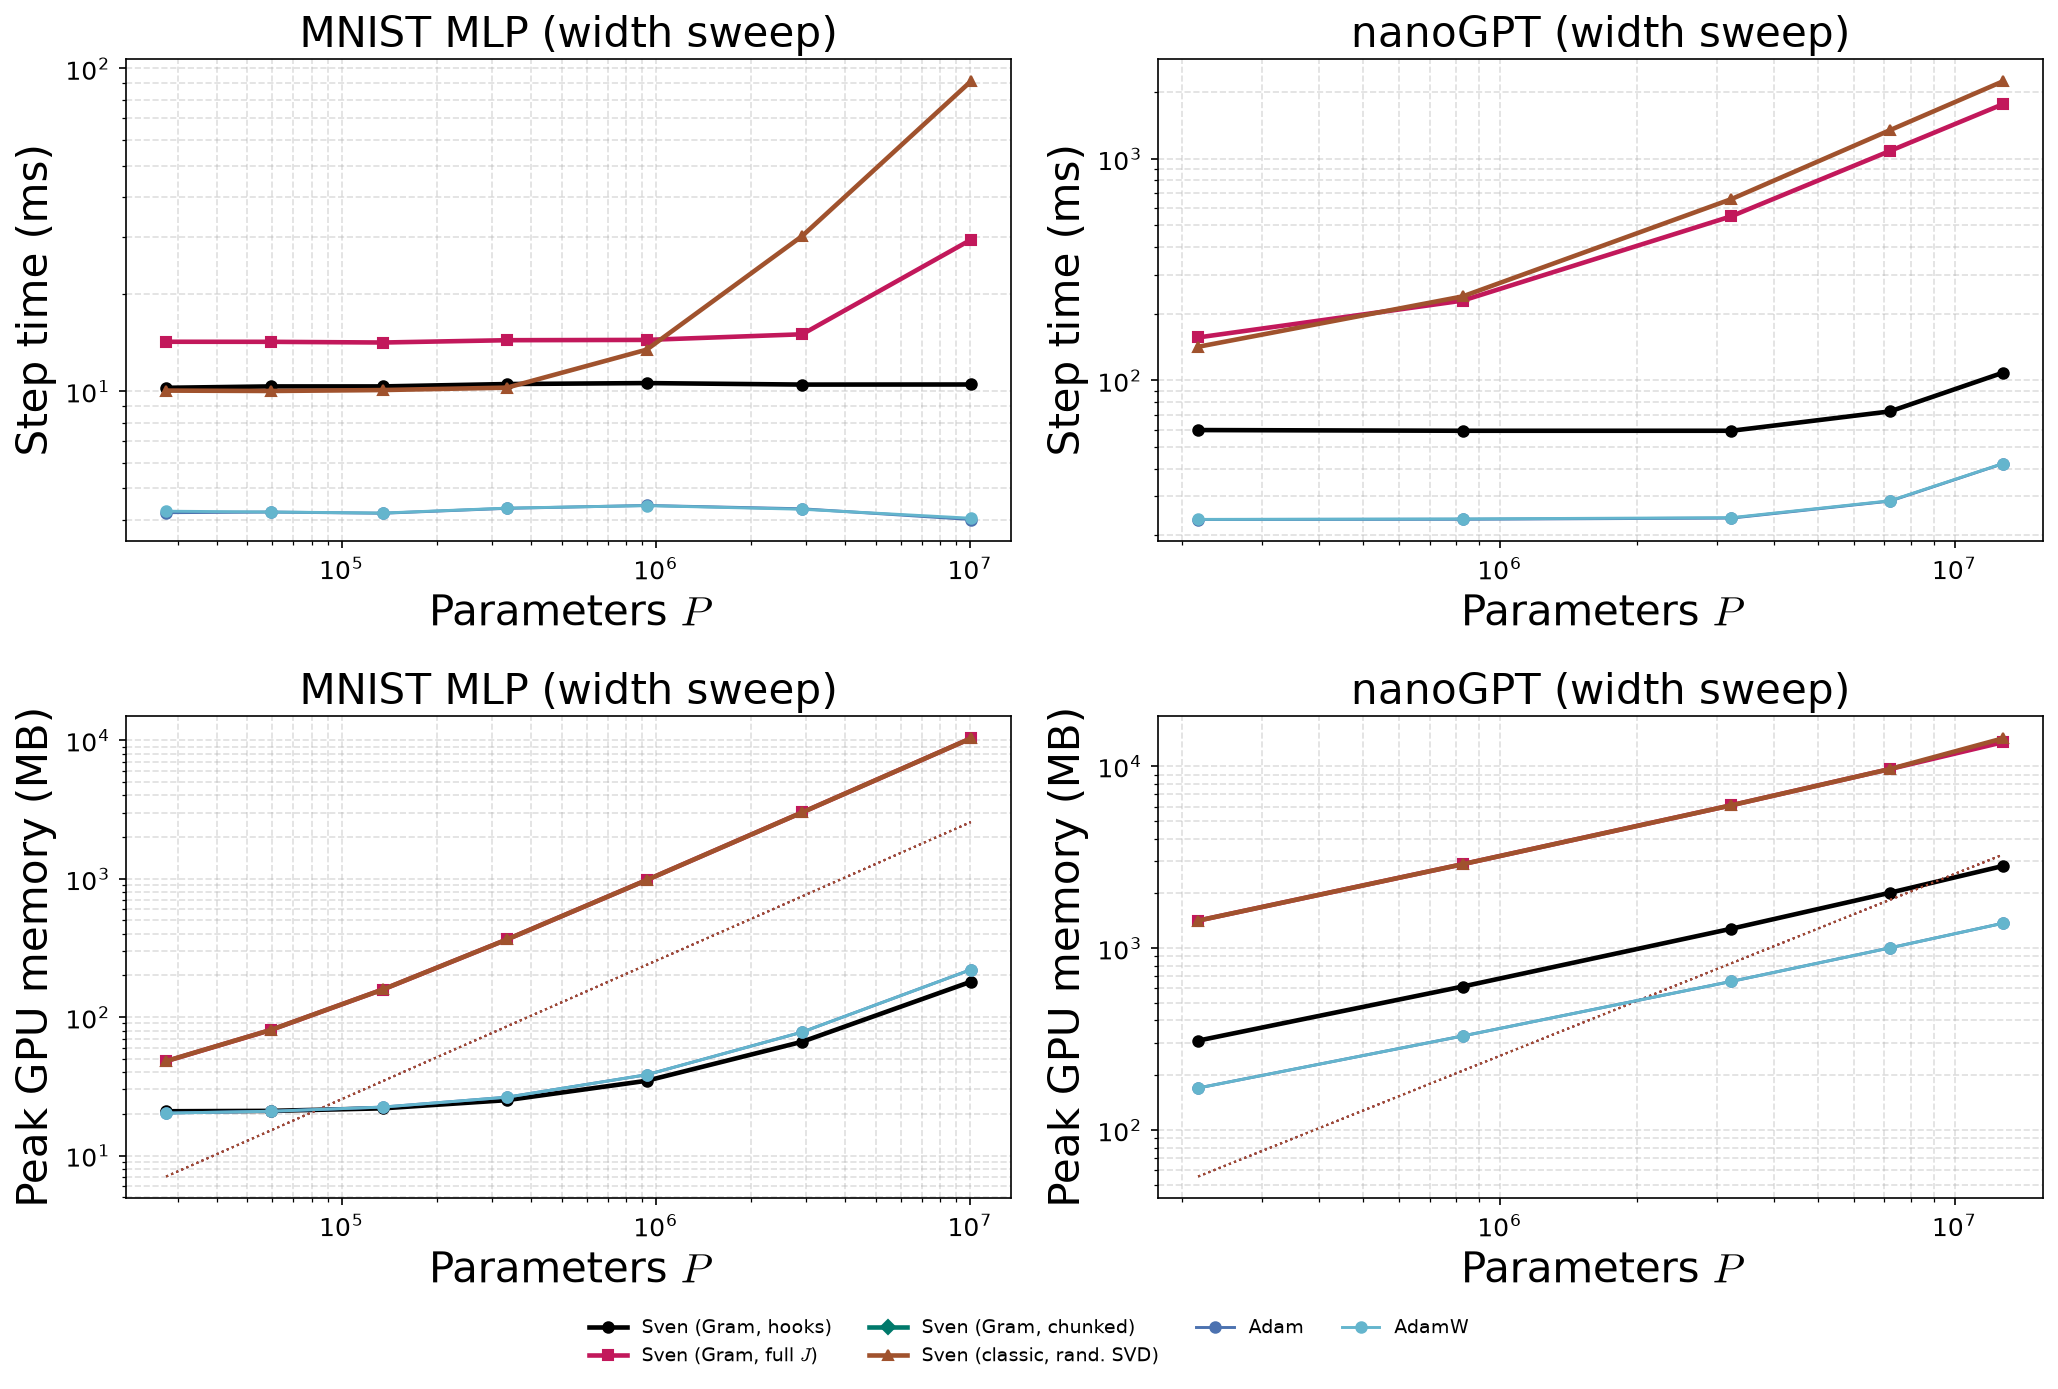

In [3]:
fig, axes = plt.subplots(2, len(WIDTH), figsize=(7 * len(WIDTH), 9), squeeze=False)
for j, arch in enumerate(WIDTH):
    ms = ph.SVEN + ['Adam', 'AdamW']
    ph.plot_sweep(df, arch, 'width', 'n_params', axes[0][j], value='step_ms', methods=ms); axes[0][j].set_xscale('log')
    ph.plot_sweep(df, arch, 'width', 'n_params', axes[1][j], value='peak_mb', methods=ms, analytic='analytic_jac_mb'); axes[1][j].set_xscale('log')
ph.legend_below(fig, axes[0][0])
fig.tight_layout(); ph.save(fig, 'scaling_sven_variants.pdf', PLOT_DIR); plt.show()

### Fitted growth
Exponent of cost in $P$ over the upper half of the size range, and where each method first fails.

In [4]:
for arch in WIDTH:
    for value in ['step_ms', 'peak_mb']:
        t = ph.scaling_table(df, arch, value)
        print(f"\n=== {ph.ARCH_TITLES[arch]}: {value} ==="); display(t)
        t.to_csv(f'{PLOT_DIR}/table_scaling_{arch}_{value}.csv', index=False)


=== MNIST MLP (width sweep): step_ms ===


,Method,smallest P,largest timed P,at largest,growth,exponent,first failure,non-finite
0,Adam,4.21,"10,020,874",4.01,1.0,-0.01,,
1,AdamW,4.25,"10,020,874",4.04,1.0,-0.01,,
2,SGD,3.96,"10,020,874",3.74,0.9,-0.01,,
3,LBFGS (1 it.),12.6,"10,020,874",13.2,1.1,-0.01,,
4,"Sven (Gram, hooks)",10.3,"10,020,874",10.5,1.0,0.00,,
5,Muon,4.97,"10,020,874",6.69,1.3,0.05,,
6,JD (UPGrad),38,"10,020,874",73.7,1.9,0.12,,
7,"Sven (Gram, full $J$)",14.2,"10,020,874",29.5,2.1,0.15,,
8,SOAP,6.16,"10,020,874",37.3,6.1,0.38,,
9,KFAC,19.4,"10,020,874",220,11.4,0.45,,



=== MNIST MLP (width sweep): peak_mb ===


,Method,smallest P,largest timed P,at largest,growth,exponent,first failure,non-finite
0,SGD,19.9,"10,020,874",100,5.0,0.36,,
1,"Sven (Gram, hooks)",20.9,"10,020,874",180,8.6,0.49,,
2,Muon,20.2,"10,020,874",190,9.4,0.50,,
3,Adam,20.3,"10,020,874",220,10.9,0.53,,
4,AdamW,20.3,"10,020,874",220,10.9,0.53,,
5,KFAC,38,"10,020,874",487,12.8,0.58,,
6,SOAP,43.2,"10,020,874",598,13.8,0.59,,
7,Shampoo,27.6,"10,020,874",480,17.4,0.65,,
8,LBFGS (1 it.),23.3,"10,020,874","1,302",56.0,0.84,,
9,JD (UPGrad),34.1,"10,020,874","5,271",154.4,0.95,,



=== nanoGPT (width sweep): step_ms ===


,Method,smallest P,largest timed P,at largest,growth,exponent,first failure,non-finite
0,LBFGS (1 it.),79.4,"12,742,656",124,1.6,0.13,,
1,Muon,30,"12,742,656",46.7,1.6,0.13,,
2,AdamW,23.6,"12,742,656",42.1,1.8,0.19,,
3,Adam,23.6,"12,742,656",42.1,1.8,0.19,,
4,"Sven (Gram, hooks)",59.7,"12,742,656",108,1.8,0.20,,
5,SGD,21,"12,742,656",41.5,2.0,0.23,,
6,SOAP,40.5,"12,742,656",89.8,2.2,0.25,,
7,JD (UPGrad),163,"12,742,656","1,861",11.4,0.71,,
8,"Sven (Gram, full $J$)",156,"12,742,656","1,760",11.3,0.74,,
9,"Sven (classic, rand. SVD)",142,"12,742,656","2,232",15.7,0.82,,



=== nanoGPT (width sweep): peak_mb ===


,Method,smallest P,largest timed P,at largest,growth,exponent,first failure,non-finite
0,SGD,168,"12,742,656","1,267",7.5,0.50,,
1,Muon,169,"12,742,656","1,319",7.8,0.51,,
2,Adam,170,"12,742,656","1,369",8.1,0.52,,
3,AdamW,170,"12,742,656","1,369",8.1,0.52,,
4,Shampoo,178,"3,225,600",786,4.4,0.55,"error @ P=7,197,696",
5,JD (UPGrad),"1,492","12,742,656","14,011",9.4,0.56,,
6,"Sven (Gram, hooks)",310,"12,742,656","2,826",9.1,0.56,,
7,"Sven (Gram, full $J$)","1,416","12,742,656","13,545",9.6,0.56,,
8,"Sven (classic, rand. SVD)","1,416","12,742,656","14,223",10.0,0.58,,
9,SOAP,176,"12,742,656","1,728",9.8,0.58,,


### Relative to Adam

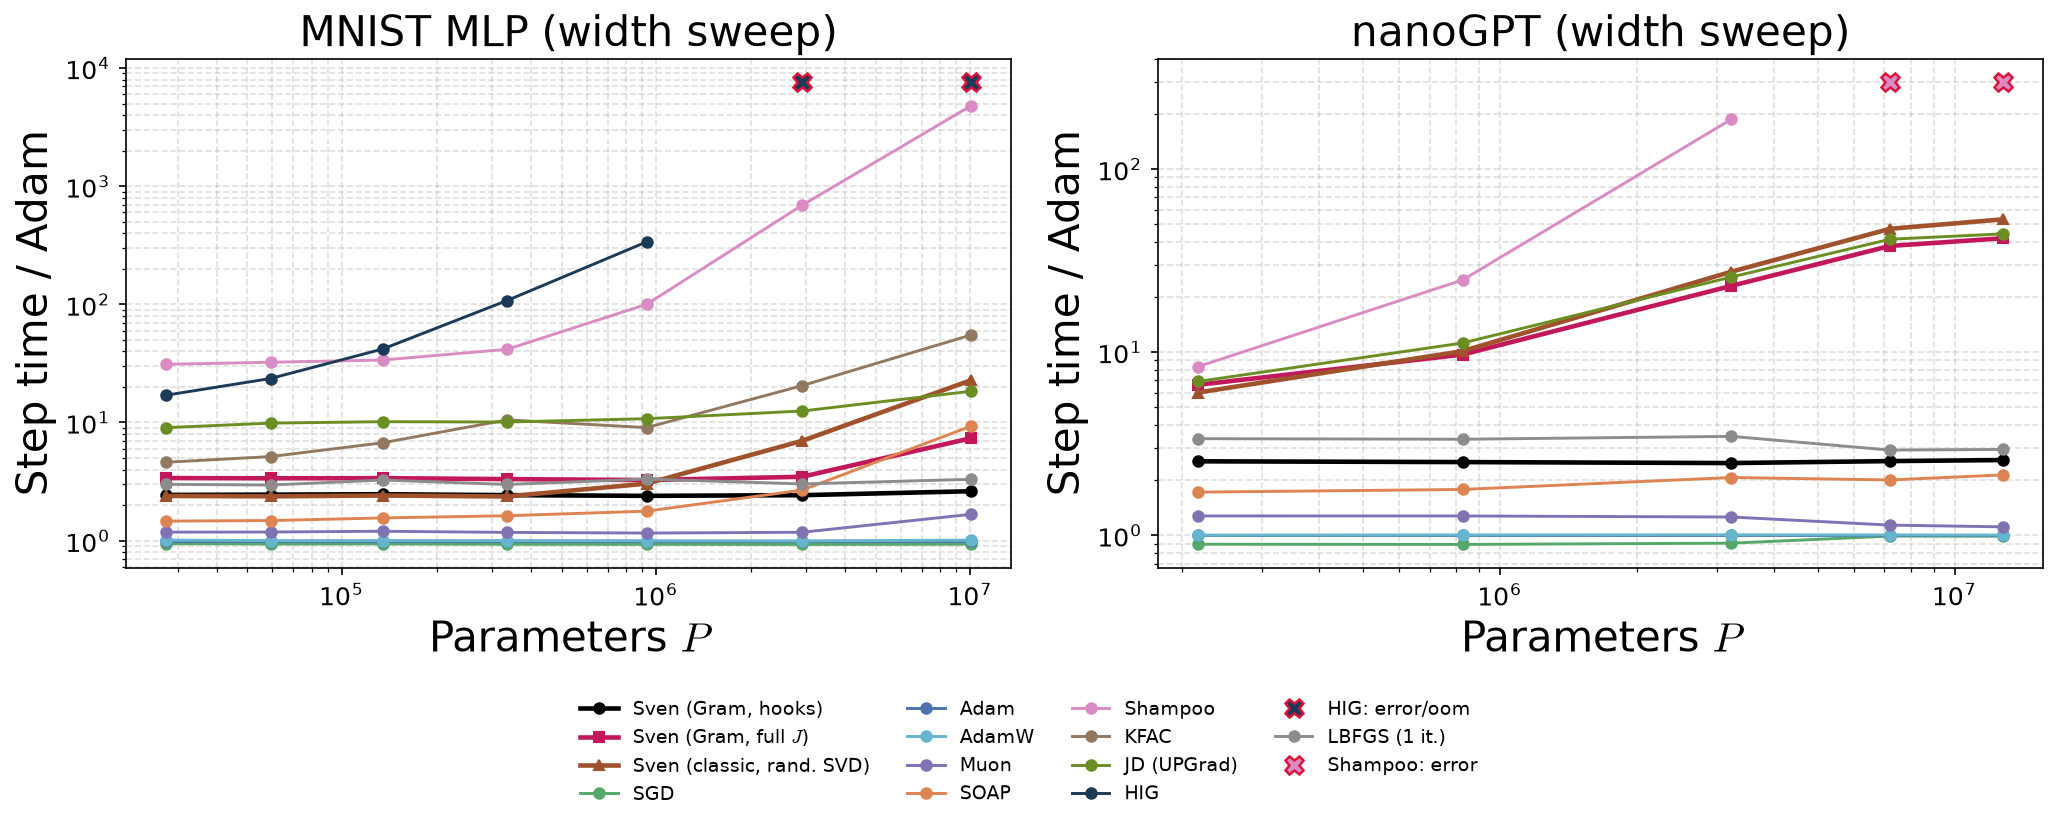

In [5]:
fig, axes = plt.subplots(1, len(WIDTH), figsize=(7 * len(WIDTH), 4.8), squeeze=False)
for ax, arch in zip(axes[0], WIDTH):
    ph.plot_sweep(df, arch, 'width', 'n_params', ax, value='rel_time'); ax.set_xscale('log'); ax.set_ylabel('Step time / Adam')
ph.legend_below(fig, axes[0][0])
fig.tight_layout(); ph.save(fig, 'scaling_relative_to_adam.pdf', PLOT_DIR); plt.show()